In [13]:
import pandas as pd
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [14]:
# Cargar el dataset de Premier League
df_pl = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/fbref_PL_2024-25.csv")
df_pl.head()

,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,...,Gls.1,Ast.1,G+A.1,G-PK.1,G+A-PK,xG.1,xAG.1,xG+xAG,npxG.1,npxG+xAG.1
0,1,Max Aarons,eng ENG,DF,Bournemouth,24.0,2000.0,3,1,86,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,2,Joshua Acheampong,eng ENG,DF,Chelsea,18.0,2006.0,4,2,170,...,0.00,0.00,0.00,0.00,0.00,0.12,0.00,0.12,0.12,0.12
2,3,Tyler Adams,us USA,MF,Bournemouth,25.0,1999.0,28,21,1965,...,0.00,0.14,0.14,0.00,0.14,0.07,0.05,0.12,0.07,0.12
3,4,Tosin Adarabioyo,eng ENG,DF,Chelsea,26.0,1997.0,22,15,1409,...,0.06,0.06,0.13,0.06,0.13,0.06,0.01,0.07,0.06,0.07
4,5,Simon Adingra,ci CIV,"FW,MF",Brighton,22.0,2002.0,29,12,1097,...,0.16,0.16,0.33,0.16,0.33,0.20,0.20,0.40,0.20,0.40


In [15]:
# Información general del dataset
df_pl.info()
df_pl.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 574 entries, 0 to 573
Data columns (total 36 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Rk          574 non-null    int64  
 1   Player      574 non-null    object 
 2   Nation      570 non-null    object 
 3   Pos         574 non-null    object 
 4   Squad       574 non-null    object 
 5   Age         570 non-null    float64
 6   Born        570 non-null    float64
 7   MP          574 non-null    int64  
 8   Starts      574 non-null    int64  
 9   Min         574 non-null    int64  
 10  90s         574 non-null    float64
 11  Gls         574 non-null    int64  
 12  Ast         574 non-null    int64  
 13  G+A         574 non-null    int64  
 14  G-PK        574 non-null    int64  
 15  PK          574 non-null    int64  
 16  PKatt       574 non-null    int64  
 17  CrdY        574 non-null    int64  
 18  CrdR        574 non-null    int64  
 19  xG          574 non-null    f

,Rk,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,...,Gls.1,Ast.1,G+A.1,G-PK.1,G+A-PK,xG.1,xAG.1,xG+xAG,npxG.1,npxG+xAG.1
count,574.000000,570.000000,570.000000,574.000000,574.000000,574.000000,574.000000,574.000000,574.000000,574.000000,...,574.000000,574.000000,574.000000,574.000000,574.000000,574.000000,574.000000,574.000000,574.000000,574.000000
mean,287.500000,25.098246,1998.526316,20.151568,14.564460,1308.240418,14.535366,1.885017,1.400697,3.285714,...,0.108362,0.080767,0.189233,0.103659,0.184564,0.142909,0.094059,0.236603,0.138171,0.231777
std,165.843802,4.450568,4.476477,12.230609,12.304536,1053.645962,11.707284,3.537979,2.253498,5.218296,...,0.179531,0.156157,0.264714,0.172322,0.257252,0.287692,0.120146,0.329482,0.284002,0.324603
min,1.000000,15.000000,1985.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,144.250000,22.000000,1996.000000,9.000000,3.000000,331.250000,3.700000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.012500,0.010000,0.050000,0.010000,0.050000
50%,287.500000,25.000000,1999.000000,21.000000,12.000000,1103.500000,12.250000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.090000,0.000000,0.085000,0.070000,0.060000,0.140000,0.070000,0.140000
75%,430.750000,28.000000,2002.000000,32.000000,25.000000,2204.000000,24.500000,2.000000,2.000000,4.000000,...,0.150000,0.127500,0.290000,0.140000,0.290000,0.190000,0.140000,0.347500,0.170000,0.340000
max,574.000000,39.000000,2008.000000,38.000000,38.000000,3420.000000,38.000000,29.000000,18.000000,47.000000,...,1.640000,2.650000,2.650000,1.640000,2.650000,5.060000,1.450000,5.060000,5.060000,5.060000


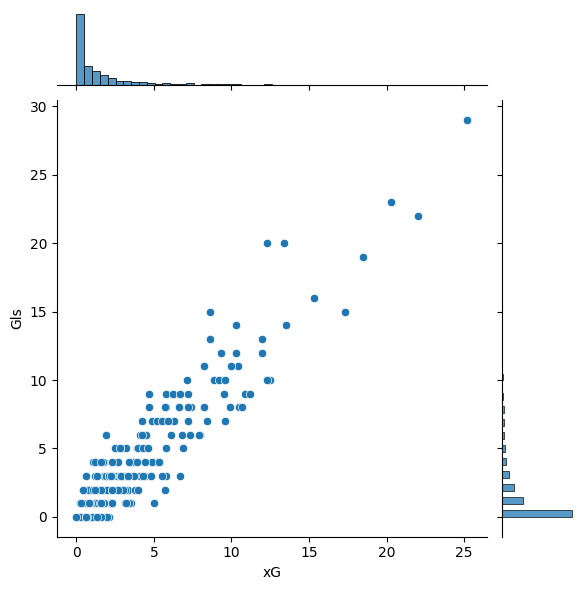

In [16]:
# Visualización inicial (Expected Goals vs Goals)
sns.jointplot(x="xG", y="Gls", data=df_pl)

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
# Variables independientes y dependientes
X = df_pl[["xG"]]
y = df_pl["Gls"]

In [19]:
# Partición en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)
print(X_train.shape)

(430, 1)


In [20]:
from sklearn.linear_model import LinearRegression

In [21]:
# Crear y entrenar el modelo
regressor = LinearRegression(fit_intercept=True)
regressor.fit(X_train, y_train)

LinearRegression()

In [22]:
print(f"La pendiente del modelo (B) es: {regressor.coef_}, el intercepto (A) es {regressor.intercept_}")

La pendiente del modelo (B) es: [1.02814481], el intercepto (A) es -0.10322602491081811


In [23]:
# Predicciones
y_pred = regressor.predict(X_test)

Text(0.5, 1.0, 'Relación entre Disparos y Goles (train data)')

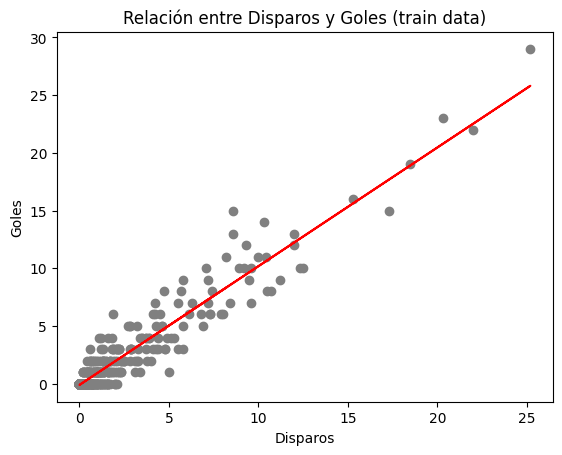

In [24]:
# Visualización de train set
plt.scatter(X_train, y_train, color='gray')
plt.plot(X_train, regressor.predict(X_train), color='red')
plt.ylabel('Goles')
plt.xlabel('Disparos')
plt.title('Relación entre Disparos y Goles (train data)')

Text(0.5, 1.0, 'Relación entre Disparos y Goles (test data)')

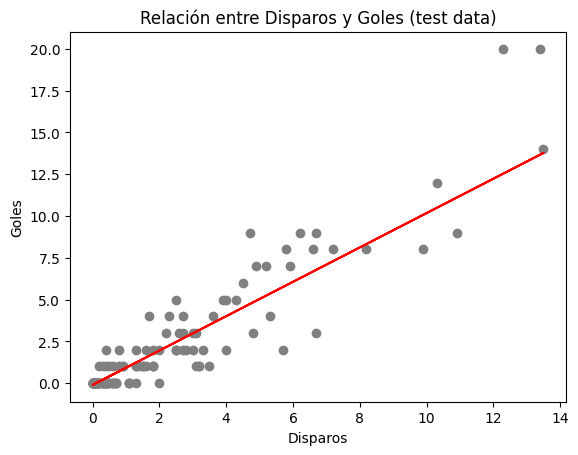

In [25]:
# Visualización de test set
plt.scatter(X_test, y_test, color='gray')
plt.plot(X_test, regressor.predict(X_test), color='red')
plt.ylabel('Goles')
plt.xlabel('Disparos')
plt.title('Relación entre Disparos y Goles (test data)')

In [26]:
# Evaluación del modelo
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("R^2:", r2_score(y_test, y_pred))

Mean Squared Error: 1.8107426162897626
Root Mean Squared Error: 1.345638367574945
Mean Absolute Error: 0.7753402150316943
R^2: 0.8498716173281227
